# HW2 - Classification

AE 598 Homework 2

Amanda Yaklin (yaklin2@illinois.edu)
9/26/2026


The goal of this program is to predict whether a flight will be delayed 
at least 15 minutes based on the carrier, origin airport, destination 
airport, departure time block, and arrival time block. 
Time blocks are 1 hour each. The prediction is done using a KNN algorithm and Logistic Regression.

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_curve, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin

# Setup 
# sklearn code template generated using Gemini
# BTS flight data obtained from December 2025

# 0. Declare global variables
FILENAME = 'T_ONTIME_REPORTING.csv'
COLUMNS = ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME_BLK','ARR_TIME_BLK','ARR_DEL15']
SAMPLE_FRACTION = 0.07

# 1. Import flight data
data = pd.read_csv(FILENAME, usecols=COLUMNS)
data = pd.DataFrame(data)
data = data.dropna()
#print(data) #debug
# Only use a sample of the available data (to reduce runtime) 
sampled_data = data.sample(frac=SAMPLE_FRACTION, random_state=1)

y = sampled_data['ARR_DEL15']
X = sampled_data.drop(columns=['ARR_DEL15'])
#print(y) #debug

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
                                                    random_state=1)
#print(y_test.shape) #debug

# 2. Select columns to preprocess
categorical_cols = COLUMNS[:-1]

# 3. Create preprocessor for categorical data
# drop='first' prevents multicollinearity 
# (linearly dependent predictors produce a model with infinite possible solutions)
encoder = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', encoder, categorical_cols)
    ]
)

def auc(X_test, y_test, model_pipeline, dx = 0.01, plot=False):
    # Obtain ROC curve and area under curve (AUC)
    y_scores = model_pipeline.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    auc = np.trapz(tpr, fpr, dx=dx)
    print('area under curve    ', auc)
    if plot:
        fig = plt.figure(figsize=[4,4])
        plt.plot(fpr,tpr)
        plt.xlabel('FPR')
        plt.ylabel('TPR')
        plt.title('Receiver Operating Characteristic Curve')

from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np


print('setup complete')


setup complete


k     2
mean squared error     0.2977394779567878
area under curve     0.5428035497517882
k     3
mean squared error     0.33945297864368673
area under curve     0.5521010622804629
k     4
mean squared error     0.2937429748969651
area under curve     0.555067992562305
k     5
mean squared error     0.31672286749094547
area under curve     0.5662891270154911
k     6
mean squared error     0.28774822030723113
area under curve     0.5643189014127528
k     7
mean squared error     0.3066067191207693
area under curve     0.5677351399606072
k     8
mean squared error     0.2869988759835145
area under curve     0.5694063777763433
k     9
mean squared error     0.2993630573248408
area under curve     0.5700429273407721
k     10
mean squared error     0.28200324715873615
area under curve     0.5734128771001176


Text(0.5, 0, 'No. of nearest neighbors')

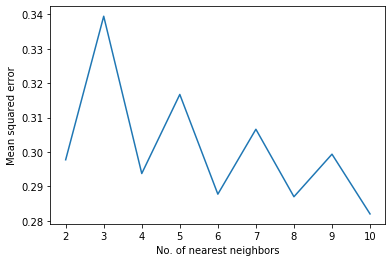

In [101]:
# Part A: KNN classification (WARNING takes several minutes depending on no. of samples)
def get_knn_fit(k):
    print('k    ',k)
    # 4. Chain the preprocessor and model into a single Pipeline
    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors = k))
    ])

    # 5. Fit the entire pipeline on training data
    model_pipeline.fit(X_train, y_train)

    # 6. Make and test prediction
    y_predicted = model_pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_predicted)
    error_rate = 1 - accuracy # same as MSE
    print('mean squared error    ', error_rate)
    auc(X_test, y_test, model_pipeline)
    return error_rate

ks = [2,3,4,5,6,7,8,9,10]
mses = []
for k in ks:
    mses.append(get_knn_fit(k))
plt.plot(ks, mses)
plt.ylabel('Mean squared error')
plt.xlabel('No. of nearest neighbors')

MSE shows oscillating decline with respect to the number of nearest neighbors (k) used in the k-NN algorithm. The exact plot will vary somewhat with different random samples of the raw data. 
For low values of k, the model may be overfit, meaning the prediction is affected by small, local variations in the data, which can result in high MSE. As k increases, the prediction is made based on a larger pool of data, which tends to result in lower MSE. 
Oscillations are a bit harder to explain. If each addition to k switches the value of the prediction, the curve will oscillate. Furthermore, since the k-NN algorithm is unweighted, each new neighbor may have an outsize impact on the error.

              precision    recall  f1-score   support

     delayed       0.74      0.99      0.85     84045
     on-time       0.50      0.01      0.03     30340

    accuracy                           0.73    114385
   macro avg       0.62      0.50      0.44    114385
weighted avg       0.67      0.73      0.63    114385

error rate     0.26524456878087166
area under curve     0.6157640706180687


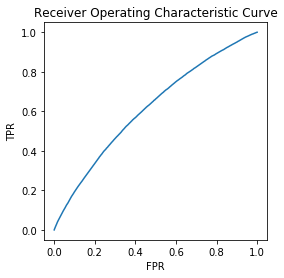

In [ ]:
# Part B: logistic regression
# sklearn code template generated using Gemini
# BTS data obtained from December 2025

# 4. Chain the preprocessor and model into a single Pipeline
# solver='liblinear' fixes sklearn error: 'str' has no attribute 'decode'
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# 5. Fit the entire pipeline on training data
model_pipeline.fit(X_train, y_train)

# 6. Basic prediction evaluation
# precision:
# of all positive predictions, how many were true positive
# = true positive rate / (true positive rate + false positive rate)

# recall:
# of all actual positives in the data, how many were correctly predicted
# actual positives = true positives + false negatives
# = true positive rate / (true positive rate + false negative rate)

# f1 score:
# combine precision and recall metrics to obtain more comprehensive result
# = 2*precision*recall/(precision+recall)
y_pred = model_pipeline.predict(X_test)
target_names = ['delayed','on-time']
print(classification_report(y_test, y_pred,target_names=target_names))

# 7. Obtain error rate
accuracy = accuracy_score(y_test,y_pred)
error_rate = 1 - accuracy
print('error rate    ', error_rate)

# 8. Obtain AUC
auc(X_test, y_test, model_pipeline, plot=True)



The 'delayed' prediction correctly classifies flights about 3/4 of the time. The corresponding recall of 0.99 indicates that it only misses 1% of the actual population of delayed flights. On the other hand, the prediction of on-time flights only has a precision of 0.5 and recall of 0.01. This means that the model correctly classifies flights as on-time 50% of the time and misses 99% of the actual on-time flights. This can be explained by the fact that ~1/4 of all flights were delayed in the month of December 2025, and thus a greater diversity of parameter inputs correspond to on-time than delayed flights. 